Exam. Node Classification
by dr.seungchul@gmail.com

In [6]:
import os
import torch
import pandas as pd
!pip install torch-geometric
from torch_geometric.data import Data
import torch.nn.functional as F
from torch_geometric.nn import GCNConv, GATConv
from torch.utils.data import TensorDataset, DataLoader
from torch_geometric.utils import to_networkx
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
from torch.nn import Linear
import torch_geometric.transforms as T
from torch_geometric.datasets import Planetoid
from torch_geometric.nn import GraphNorm
from sklearn import preprocessing as pp

**************************************************
Number of nodes 37700
Number of node feauturs 0
Number of node classes 2
Number of edges 289003
Number of edge feauturs 0
MyGCN(
  (conv1): GCNConv(0, 8)
  (norm): GraphNorm(8)
  (conv2): GCNConv(8, 2)
)


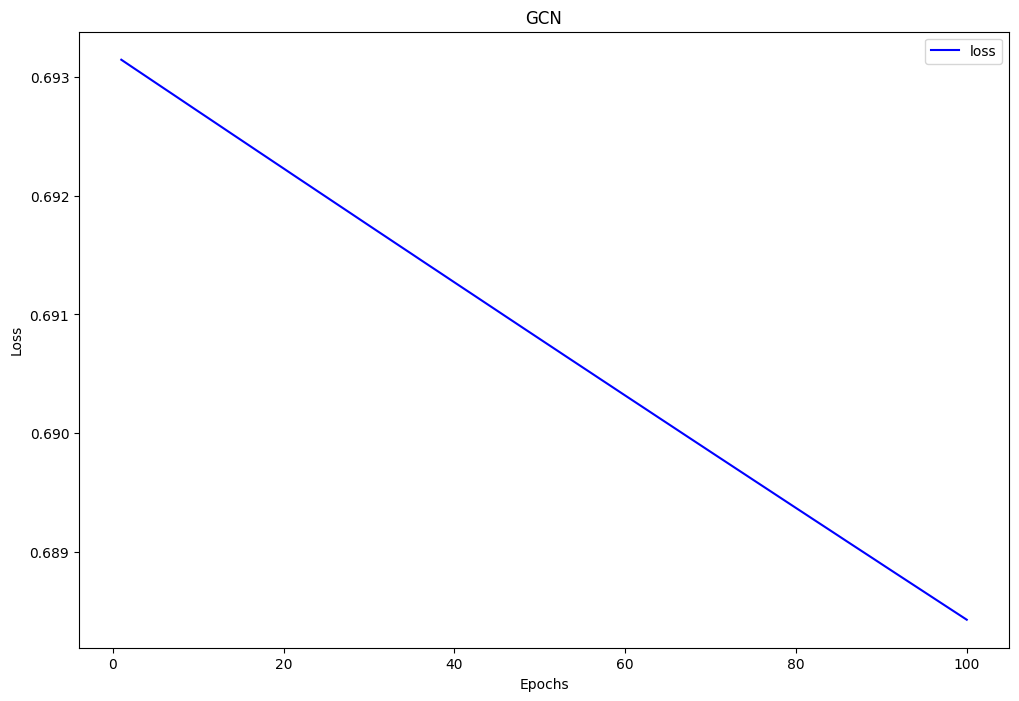

Accuracy: 0.7442


In [7]:
########### 수정가능 부분
HID_DIM = 8
EPOCHS = 100
LEARNING_RATE = 0.0001
HEADS = 8
DROPOUT = 0.3
TEST_SIZE = 0.2
VAL_SIZE = 0
###########


# read files
df_node = pd.read_csv('node.csv')
node_feats = df_node.columns[2:]
node_ids = df_node['title'].unique()
le_node = pp.LabelEncoder().fit(node_ids)
df_node['node_idx'] = le_node.transform(node_ids)
labels = df_node['label'].unique()
num_classes = len(labels)

df_edge = pd.read_csv("edge.csv")
edge_feats = df_edge.columns[2:]
df_edge['src_idx'] = le_node.transform(df_edge['src'])
df_edge['dst_idx'] = le_node.transform(df_edge['dst'])

print(50*'*')
print('Number of nodes', len(node_ids))
print('Number of node feauturs', len(node_feats))
print('Number of node classes', num_classes)
print('Number of edges', len(df_edge))
print('Number of edge feauturs', len(edge_feats))


# graph
x = []
for i, row in df_node.iterrows():
  feats = row[2:2+len(node_feats)]
  x.append(feats)
x = torch.tensor(x, dtype=torch.float)

le_label = pp.LabelEncoder().fit(labels)
y = le_label.transform(df_node['label']).tolist()
y = torch.tensor(y)

srcs = list(df_edge['src_idx'])
dsts = list(df_edge['dst_idx'])
zip1 = list(zip(srcs, dsts))
zip1 = [list(item) for item in zip1]
zip2 = list(zip(dsts, srcs))
zip2 = [list(item) for item in zip2]
zipped = zip1+zip2
edge_index = torch.tensor(zipped)

e_f = []
for i, row in df_edge.iterrows():
  feats = row[2:2+len(edge_feats)]
  e_f.append(feats)
e_f = e_f + e_f
edge_attr = torch.tensor(e_f, dtype=torch.float)

graph = Data(x=x, edge_index=edge_index.t().contiguous(), y=y, edge_attr=edge_attr)
graph.num_nodes = len(node_ids)
graph.num_edges = len(df_edge)
graph.num_classes = num_classes
graph.node_feats = graph.x.shape[1]
graph.edge_feats = graph.edge_attr.shape[1]
graph.validate(raise_on_error=True)

split = T.RandomNodeSplit(num_val=VAL_SIZE, num_test=TEST_SIZE)
graph = split(graph)
graph


class MyGCN(torch.nn.Module):
############# 수정가능 부분
    def __init__(self, graph, hid_dim):
        super(MyGCN, self).__init__()
        self.conv1 = GCNConv(graph.num_node_features, hid_dim)
        self.norm = GraphNorm(hid_dim)
        self.conv2 = GCNConv(hid_dim, graph.num_classes)

    def forward(self, graph):
        x, edge_index = graph.x, graph.edge_index
        x = self.conv1(x, edge_index)
        x = self.norm(x)
        x = F.relu(x)
        x = self.conv2(x, edge_index)
        return x
##############

model = MyGCN(graph, HID_DIM)
print(model)

############# 수정가능 부분
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
loss_function = torch.nn.CrossEntropyLoss()
##############


model.train()
losses = []
for  epoch in range(EPOCHS):
    optimizer.zero_grad()
    out = model(graph)
    loss = loss_function(out, graph.y)
    loss.backward()
    optimizer.step()
    losses.append(loss.item())

plt.figure(figsize=(12,8))
plt.title('GCN')
plt.xlabel('Epochs')
plt.ylabel('Loss')
losses_np = np.array(losses)
epoch_range = np.arange(1,EPOCHS+1)
plt.plot(epoch_range, losses_np, color='blue', label='loss')
plt.legend()
plt.show()

model.eval()
with torch.no_grad():
  out = model(graph)
  pred = out.argmax(dim=1)
  test_correct = pred[graph.test_mask] == graph.y[graph.test_mask]
  test_acc = int(test_correct.sum()) / int(graph.test_mask.sum())
  print(f'Accuracy: {test_acc:.4f}')